# Vietnam — F-Score grid study: basket k = 25, random draws = 1000

One cell of the reviewer-suggested 3 x 3 x 2 grid (basket sizes 20/25/30 x
random-sample sizes 1,000/2,000/5,000 x two markets). Signals come from the
the team's FS_clean statements, scored by this repository's own signal code
(`fscore.signal.piotroski`, unit-tested, beginning-of-year asset scaling on
both sides of every delta); prices from the cached Yahoo data. Formations are
July 1 of **2012-2025** (14 chained holding years) using score year T-1 —
one conservative timing rule for both markets, over identical calendar time
so the two are comparable. The evaluation window ends 2025-12-31.
Covariances are estimated on 36 months of daily returns ending the day
before formation. Note the panel resolves to *currently listed* symbols, so
the universe is survivorship-tilted — disclosed as a data limitation. The value control falls back to the universe
in years before B/M coverage begins (flagged in the diagnostics).

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW
and plain universe minimum-variance controls; a dollar-neutral long-short
book (long top-k scores, short bottom-k, charged both legs' trading costs
plus a stock-borrow fee) wherever shorting is available — Vietnam runs
long-only, so `fscore_LS` is simply absent there; denoised
(not detoned) GMV;
primary measure fixed in advance = net-of-cost Sharpe (20 bp per side,
rf = 0); and the synergy test D = Sharpe(GMV) − Sharpe(EW) computed per
basket. All figures are saved at dpi = 300.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.fs_clean import exclusion_report, load_scores
from fscore.data.team_scores import sectors_from_scores
from fscore.grid import run_grid
from fscore.plotting import setup_plots, save_fig

setup_plots()          # study-wide figure defaults; every saved chart is 300 dpi
MARKET, K, N_MC = "vietnam", 25, 1000
YEARS = list(range(2012, 2026))
FIG = ROOT / "results" / "figures"
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)
TAG = "vietnam_k30_mc1000"

scores = load_scores(MARKET, ROOT / "data")   # our own signal code
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)
study = run_grid(MARKET, scores, prices, sectors, YEARS, k=K, n_mc=N_MC,
                 n_gmv=300, seed=42)
diag = study.diagnostics()
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,tie_break_slots,overlap_random_vs_fscore,overlap_expected,cov_est_days,cov_min_est_days,delisted_in_holding_year,no_price_after_formation,long_short_run,short_leg_max_fscore
year,,,,,,,,,,,,,,,,,,
2012,303,26,303,25,False,25,25,4.696,8.0,19,0.081,0.083,749,374,7,0,False,NaN
2013,408,8,408,25,False,25,28,4.907,8.0,18,0.064,0.061,746,373,18,0,False,NaN
2014,421,8,421,25,False,25,51,5.314,8.0,11,0.062,0.059,746,373,9,0,False,NaN
2015,457,16,457,25,False,25,67,5.573,8.0,14,0.056,0.055,743,371,4,0,False,NaN
2016,471,44,471,25,False,25,44,5.325,8.0,15,0.053,0.053,746,373,0,0,False,NaN
2017,510,43,510,25,False,25,60,5.345,8.0,12,0.047,0.049,749,374,5,0,False,NaN
2018,476,64,476,25,False,25,53,5.164,8.0,10,0.050,0.053,752,376,1,0,False,NaN
2019,546,40,546,25,False,25,52,5.245,8.0,12,0.045,0.046,748,374,2,0,False,NaN
2020,671,19,671,25,False,25,82,5.414,8.0,8,0.038,0.037,750,375,5,0,False,NaN


### 0. Data discarded before any test

A firm-year enters the study only with a **complete nine-signal F-Score**.
Partial scores are dropped rather than summed over whatever is available —
an incomplete score is not a low score, and keeping them would push those
firms towards the bottom of the ranking and into the short leg.

Three things remove rows, counted separately because they mean different
things: an identifier that never resolved to a tradable symbol, a year with
no prior-year row to difference against, and a year whose nine signals were
not all computable. `dropped_no_price` in the diagnostics above counts the
further names removed for insufficient price history.

In [3]:
drops_total = exclusion_report(MARKET, ROOT / "data")
drops_year = exclusion_report(MARKET, ROOT / "data", by_year=True)
drops_total.to_csv(OUT / f"{TAG}_exclusions.csv")
r = drops_total.iloc[0]
print(f"{MARKET.upper()}: {int(r.rows_in_source)} firm-years in the source -> "
      f"{int(r.scored)} scored ({r.pct_scored:.1f}%)")
print(f"  identifier never resolved to a tradable symbol: {int(r.dropped_unresolved_identifier)}")
print(f"  no prior-year row to difference against:        {int(r.dropped_no_prior_year)}")
print(f"  nine signals not all computable:                {int(r.dropped_incomplete_signals)}")
drops_total

KeyError: 'vietnam'

### 1. Summary (primary measure: net-of-cost Sharpe; rf = 0)

Costs are 20 bp per side charged on each strategy's **own** one-way turnover,
computed from its actual weights — so the optimised portfolios pay for weight
drift and the near-static universe control pays almost nothing. The
long-short book (`fscore_LS`, present only where shorting is available) pays
both legs plus a 100 bp annual stock-borrow fee on its short notional.

In [4]:
summary = study.summary()
summary[["ann_return", "ann_vol", "sharpe", "max_drawdown",
         "turnover", "cost_drag", "net_ann_return", "net_sharpe"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.263,0.155,1.702,-0.422,0.880,0.004,0.260,1.679
fscore_GMV,0.285,0.135,2.111,-0.221,0.854,0.003,0.282,2.086
fscore_GMVsec,0.264,0.145,1.816,-0.311,0.904,0.004,0.260,1.791
fscore_high_EW,0.279,0.135,2.071,-0.441,0.836,0.003,0.276,2.046
value_EW,0.350,0.241,1.452,-0.619,0.665,0.003,0.348,1.441
universe_EW,0.238,0.127,1.875,-0.452,0.222,0.001,0.237,1.868
universe_GMV,0.249,0.073,3.399,-0.219,0.635,0.003,0.246,3.365


### 2. Yearly returns (July–June holding years; final year ends Dec 2025)

In [5]:
yearly = study.yearly_returns()
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV
date,,,,,,,
2012,5.9,1.7,-0.6,5.9,-5.0,-6.1,3.9
2013,58.7,44.4,43.5,61.7,58.1,44.7,35.2
2014,62.2,68.5,70.1,55.5,54.6,42.8,42.0
2015,21.8,32.6,35.9,22.3,9.4,13.9,34.5
2016,23.7,40.6,47.7,19.8,21.0,21.6,47.7
2017,28.4,19.9,17.8,26.6,24.1,30.8,24.4
2018,10.8,13.0,10.8,12.0,-8.5,6.8,12.4
2019,9.6,8.1,14.7,8.1,42.8,15.5,13.3
2020,63.7,46.9,53.5,53.1,174.1,47.1,26.3


### 3. Placement vs the random distributions

Reported gross and net of costs. The random control is redrawn every year, so
it carries its own turnover (~1 − k/|universe|) — charging both sides is the
like-for-like comparison; the gross rows show costs are not driving it.

Significance is judged at **one level fixed in advance: 5%** (`significant`
column = p < 0.05). There is no 1% or 10% tier: p = 0.06 is not
significant.

In [6]:
rows = {}
for pool, label in [("mc_ew", "random (full universe)"),
                    ("mc_nonf_ew", "random (non-F-Score names)")]:
    frame = getattr(study, pool)
    if frame.shape[1]:
        for stat in ["sharpe", "ann_return"]:
            for net in (False, True):
                basis = "net" if net else "gross"
                rows[(label, stat, basis)] = study.placement(
                    "fscore_EW", pool, stat, net=net)
placement = pd.DataFrame(rows).T
print(f"turnover — F-Score EW {study.strategy_turnover('fscore_EW'):.3f} "
      f"vs random basket {study.mc_turnover():.3f} (one-way, per year)")
placement.round(3)

turnover — F-Score EW 0.880 vs random basket 0.964 (one-way, per year)


percentile p_value significant  \
random (full universe)     sharpe     gross      0.961   0.039        True   
                                      net        0.962   0.038        True   
                           ann_return gross      0.889   0.111       False   
                                      net        0.892   0.108       False   
random (non-F-Score names) sharpe     gross      0.959   0.041        True   
                                      net        0.959   0.041        True   
                           ann_return gross      0.895   0.105       False   
                                      net        0.897   0.103       False   

                                            alpha n_draws random_mean  \
random (full universe)     sharpe     gross  0.05    1000    1.412727   
                                      net    0.05    1000    1.389098   
                           ann_return gross  0.05    1000    0.230564   
                                      net    0.05    1000    0.226707   
random (non-F-Score names) sharpe     gross  0.05    1000     1.39306   
                                      net    0.05    1000    1.369528   
                           ann_return gross  0.05    1000    0.228318   
                                      net    0.05    1000    0.224462   

                                            random_std    fscore  basis  
random (full universe)     sharpe     gross   0.169039  1.701866  gross  
                                      net     0.168854  1.679124    net  
                           ann_return gross   0.026648   0.26342  gross  
                                      net     0.026648    0.2599    net  
random (non-F-Score names) sharpe     gross   0.173274  1.701866  gross  
                                      net      0.17312  1.679124    net  
                           ann_return gross   0.027726   0.26342  gross  
                                      net     0.027726    0.2599    net

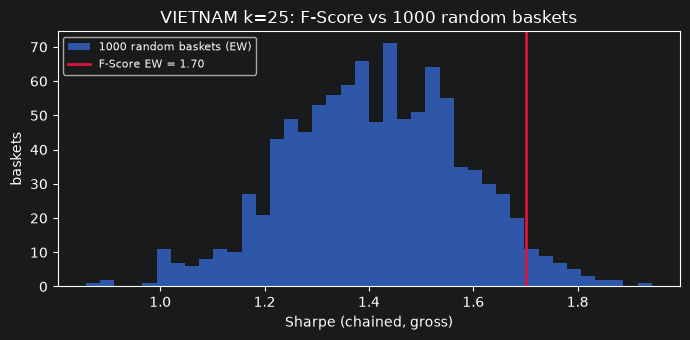

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sh = study.mc_metric(study.mc_ew, "sharpe")
ax.hist(sh, bins=40, alpha=0.75, label=f"{N_MC} random baskets (EW)")
# the placement index is (pool, statistic, basis); the histogram shows gross
fs = placement.loc[("random (full universe)", "sharpe", "gross"), "fscore"]
ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: F-Score vs {N_MC} random baskets")
plt.tight_layout()
save_fig(f"{TAG}_mc_hist", directory=FIG)
plt.show()

### 4. Synergy test: per-basket optimisation gain
D = Sharpe(GMV) − Sharpe(EW), judged at the 5% level.

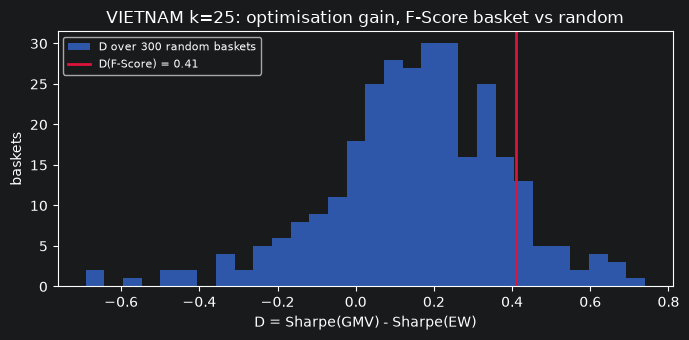

percentile       0.893
p_value          0.107
significant          0
alpha             0.05
n_draws            300
random_mean      0.155
random_std       0.225
D_fscore         0.409
D_random_mean    0.155
D_random_std     0.225
n                  300
dtype: object

In [8]:
syn = study.synergy()
d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
          - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))], "sharpe")).dropna()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
ax.axvline(syn["D_fscore"], color="crimson", lw=2,
           label=f"D(F-Score) = {syn['D_fscore']:.2f}")
ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: optimisation gain, F-Score basket vs random")
plt.tight_layout()
save_fig(f"{TAG}_synergy_hist", directory=FIG)
plt.show()
pd.Series(syn).round(3)

### 5. Track record and outputs

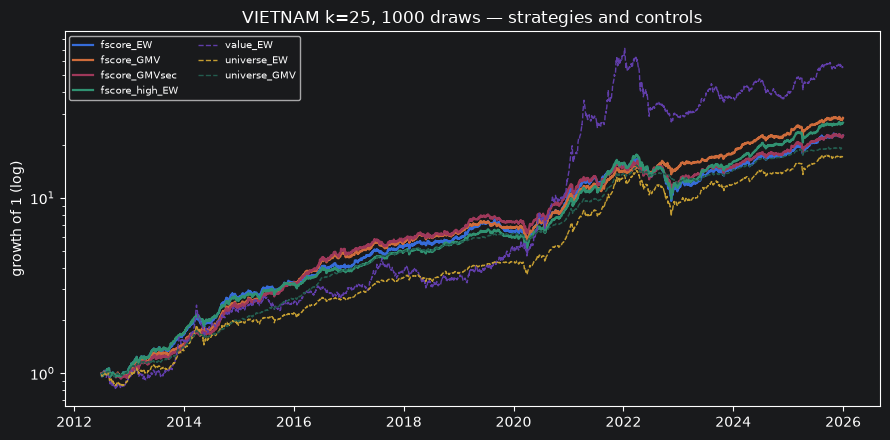

saved vietnam_k25_mc1000


In [9]:
nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in nav.columns:
    ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
            ls="-" if c.startswith("fscore") else "--", label=c)
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
ax.set_title(f"{MARKET.upper()} k={K}, {N_MC} draws — strategies and controls")
plt.tight_layout()
save_fig(f"{TAG}_nav", directory=FIG)
plt.show()

summary.to_csv(OUT / f"{TAG}_summary.csv")
placement.to_csv(OUT / f"{TAG}_placement.csv")
pd.Series(syn).to_frame("value").to_csv(OUT / f"{TAG}_synergy.csv")
yearly.to_csv(OUT / f"{TAG}_yearly_returns.csv")
diag.to_csv(OUT / f"{TAG}_diagnostics.csv")
print("saved", TAG)